In [2]:
import cv2

# Load pre-trained classifiers for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

def detect_faces_and_eyes(image):
    # Convert the image to grayscale for better detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    for (x, y, w, h) in faces:
        # Draw rectangle around the face
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)
        
        # Region of Interest (ROI) for eyes within the face
        roi_gray = gray[y:y + h, x:x + w]
        roi_color = image[y:y + h, x:x + w]
        
        # Detect eyes within the face ROI
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15))
        for (ex, ey, ew, eh) in eyes:
            # Draw rectangle around each eye
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)
    
    return image

# Initialize webcam for real-time detection
cap = cv2.VideoCapture(0)

print("Press 'q' to exit the application.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture video. Exiting...")
        break
    
    # Detect faces and eyes in the current frame
    processed_frame = detect_faces_and_eyes(frame)
    
    # Display the frame with detections
    cv2.imshow('Face and Eye Detection', processed_frame)
    
    # Exit the application when 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


Press 'q' to exit the application.


Fetching stock data...


[*********************100%***********************]  1 of 1 completed



Stock Data Sample:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.524334  40.533746  39.818581  40.030309  102223600
2018-01-03  40.517288  41.063072  40.453773  40.587864  118071600
2018-01-04  40.705482  40.808994  40.481995  40.590208   89738400
2018-01-05  41.168934  41.255976  40.710195  40.801943   94640000
2018-01-08  41.016022  41.312437  40.917213  41.016022   82271200

Model Evaluation:
Mean Squared Error (MSE): 253.94768101587763
Mean Absolute Error (MAE): 13.91738009921631


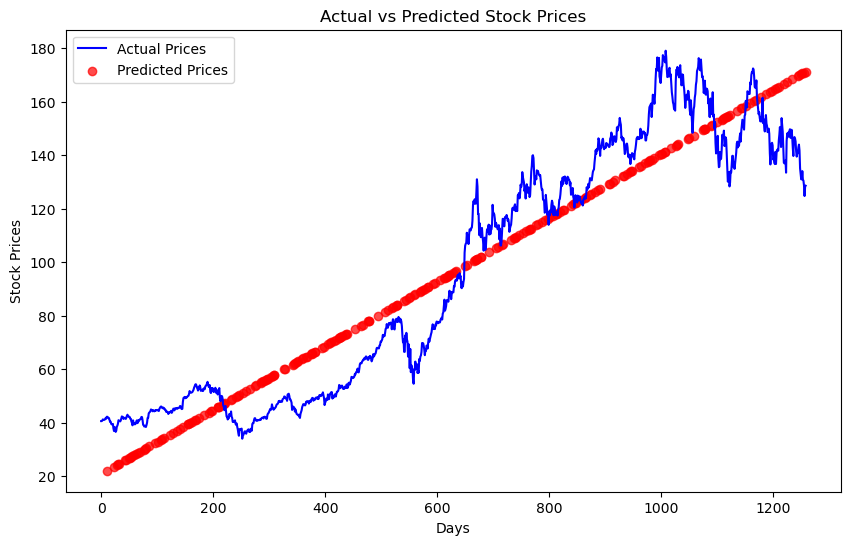


Next 30 Days Predicted Prices:
[[171.39754704]
 [171.51718411]
 [171.63682117]
 [171.75645824]
 [171.8760953 ]
 [171.99573237]
 [172.11536943]
 [172.2350065 ]
 [172.35464357]
 [172.47428063]
 [172.5939177 ]
 [172.71355476]
 [172.83319183]
 [172.95282889]
 [173.07246596]
 [173.19210303]
 [173.31174009]
 [173.43137716]
 [173.55101422]
 [173.67065129]
 [173.79028835]
 [173.90992542]
 [174.02956248]
 [174.14919955]
 [174.26883662]
 [174.38847368]
 [174.50811075]
 [174.62774781]
 [174.74738488]
 [174.86702194]]


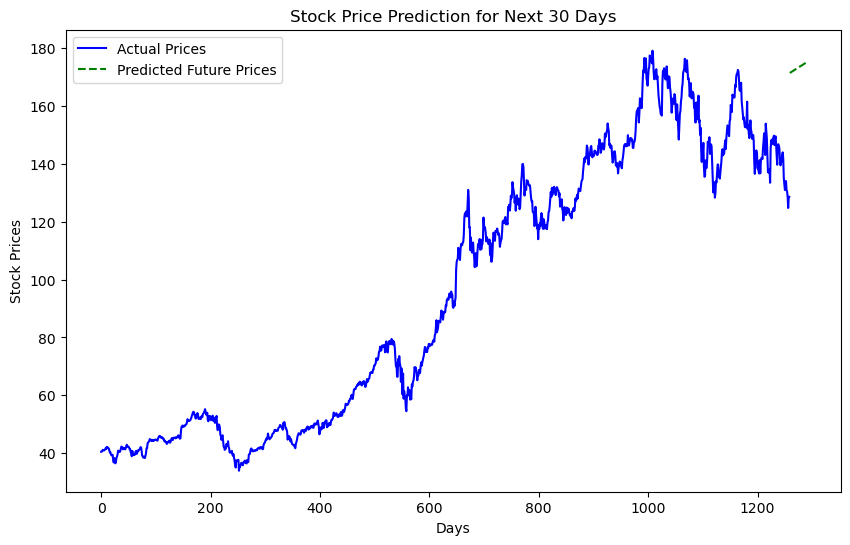

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import yfinance as yf

# Load stock price data (e.g., Apple stock data for the past 5 years)
print("Fetching stock data...")
stock_data = yf.download('AAPL', start='2018-01-01', end='2023-01-01')

# Display dataset information
print("\nStock Data Sample:")
print(stock_data.head())

# Use only the 'Close' prices for prediction
stock_data = stock_data[['Close']]
stock_data['Date'] = stock_data.index
stock_data.reset_index(drop=True, inplace=True)

# Feature engineering: Create a "Days" column
stock_data['Days'] = np.arange(len(stock_data))

# Define features and target variable
X = stock_data[['Days']]
y = stock_data['Close']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")

# Visualize actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Days'], stock_data['Close'], label="Actual Prices", color='blue')
plt.scatter(X_test, y_pred, label="Predicted Prices", color='red', alpha=0.7)
plt.xlabel("Days")
plt.ylabel("Stock Prices")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.show()

# Future prediction: Predict the next 30 days' prices
future_days = np.arange(len(stock_data), len(stock_data) + 30).reshape(-1, 1)
future_prices = model.predict(future_days)

print("\nNext 30 Days Predicted Prices:")
print(future_prices)

# Plot the predicted future prices
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Days'], stock_data['Close'], label="Actual Prices", color='blue')
plt.plot(future_days, future_prices, label="Predicted Future Prices", color='green', linestyle='--')
plt.xlabel("Days")
plt.ylabel("Stock Prices")
plt.title("Stock Price Prediction for Next 30 Days")
plt.legend()
plt.show()


In [4]:
a=55
a

55

In [5]:
type(a)

int

In [6]:
b="string"
b

'string'

In [7]:
type(string)

NameError: name 'string' is not defined

In [8]:
type(b)

str

In [9]:
b

'string'

In [10]:
b

'string'

In [11]:
a

55

In [12]:
a

55

In [13]:
a

55

In [14]:
a

55

In [15]:
b

'string'

In [16]:
b

'string'

In [17]:
b

'string'

In [18]:
b

'string'

In [19]:
b

'string'

In [20]:
b

'string'

In [21]:
type(a)

int

In [22]:
type(b)

str

In [23]:
str(a)+b

'55string'

In [24]:
print(str(a)+b)

55string


In [25]:
a

55

In [26]:
b

'string'

In [27]:
print(str(a)+b)

55string


In [28]:
str(a)+b

'55string'